## 1. Import Libraries

In [1]:
# ==========================================
# HEART ATTACK PREDICTION MODEL
# Algorithm: Support Vector Machine (SVM)
# ==========================================

# -----------------------------
# 1. Import Libraries
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


print("Libraries Loaded")


Libraries Loaded



Dataset Shape: (1888, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalachh  exang  oldpeak  \
0   63    1   3       145   233    1        0       150      0      2.3   
1   37    1   2       130   250    0        1       187      0      3.5   
2   41    0   1       130   204    0        0       172      0      1.4   
3   56    1   1       120   236    0        1       178      0      0.8   
4   57    0   0       120   354    0        1       163      1      0.6   

   slope  ca  thal  target  
0      0   0     1       1  
1      0   0     2       1  
2      2   0     2       1  
3      2   0     2       1  
4      2   0     2       1  

Train Shape: (1510, 13)
Test Shape: (378, 13)

Scaling Completed

SVM Model Trained

Accuracy: 0.91005291005291

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.93      0.91       188
           1       0.92      0.89      0.91       190

    accuracy                           0.91   

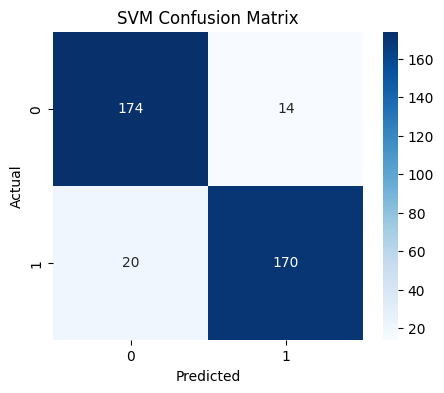


Model Saved Successfully
Files created:
svm_heart_model.pkl
svm_scaler.pkl


In [2]:

# -----------------------------
# 2. Load Dataset
# -----------------------------
df = pd.read_csv("../data/cleaned_merged_heart_dataset.csv")

print("\nDataset Shape:", df.shape)
print(df.head())

# -----------------------------
# 3. Split Features and Target
# -----------------------------
X = df.drop("target", axis=1)
y = df["target"]

# -----------------------------
# 4. Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

# -----------------------------
# 5. Feature Scaling
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling Completed")

# -----------------------------
# 6. Train SVM Model
# -----------------------------
svm_model = SVC(kernel="rbf")

svm_model.fit(X_train_scaled, y_train)

print("\nSVM Model Trained")

# -----------------------------
# 7. Predictions
# -----------------------------
y_pred = svm_model.predict(X_test_scaled)

# -----------------------------
# 8. Evaluation
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# 9. Confusion Matrix
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -----------------------------
# 10. Save Model
# -----------------------------
joblib.dump(svm_model, "svm_heart_model.pkl")
joblib.dump(scaler, "svm_scaler.pkl")

print("\nModel Saved Successfully")
print("Files created:")
print("svm_heart_model.pkl")
print("svm_scaler.pkl")